In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [ ]:
print([row['tipo_telf' ] for row in df_list.select('tipo_telf').distinct().collect()])


['BBDD ETK02', 'BBDD HU02', 'BBDD EPC01', 'BBDD CEL12', 'BBDD EIP03', 'BBDD CEL14', 'BBDD EIP01', 'BBDD EPC03', 'BBDD ETK03', 'BBDD CEL05', 'BBDD CEL07', 'BBDD CEL06', 'BBDD CEL02', 'BBDD EIP02', 'BBDD CEL15', 'BBDD CEL01', 'BBDD ETK01', 'BBDD CEL11', 'BBDD HU05', 'BBDD EINT1', 'BBDD CEL09', 'BBDD EIP05', 'BBDD CEL04', 'BBDD EINT2', 'BBDD CEL10', 'BBDD CEL03', 'BBDD ETK06', 'BBDD CEL13', 'BBDD HU04', 'BBDD ETK05', 'BBDD CEL08', 'BBDD HU03', 'BBDD HU01', 'BBDD EIP04', 'BBDD ETK04', 'BBDD EPC02']


### armar lista negocios

In [2]:

query=f'''
    select * from cronox.dbo.borrar_negocio_efe
'''
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
print(df_list.count())
print(df_list.columns)

# no_relanzable_consumo=['B001','B002','B003','B014','B018','B019','B020','B021','B023','B024','B025','B040','B041','B026']

449937
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'marca', 'fecha_envio', 'retiro', 'region', 'prioridada', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf']


In [17]:
print(df_list.select('vendor_lead_code').dropDuplicates().count())


89770


In [3]:
from pyspark.sql import functions as F

df_list = df_list.withColumn(
    "tipo_telf_ordern",
    F.when(F.lower(F.col("tipo_telf")).like("%cel%"), 1)
     .when(F.lower(F.col("tipo_telf")).like("%int%"), 2)
     .when(F.lower(F.col("tipo_telf")).like("%eip%"), 3)
     .otherwise(4)
)

window_spec = Window.partitionBy("vendor_lead_code").orderBy(F.col("tipo_telf_ordern").asc_nulls_last(),F.col("tipo_telf").asc_nulls_last())
df_list = df_list.withColumn("ordern", row_number().over(window_spec))
df_list = df_list.filter(F.col('ordern')==1).drop('ordern')

In [13]:
print(df_list.count())


89770


In [4]:
mejor_estado_tipi_cli=[ 'CONTACTO EFECTIVO', ]
mejor_descripcion_telf=[
 'VOLVER A LLAMAR',
 'LO VA A PENSAR',
 'MAL SERVICIO',
 'DESEA ELECTRO',
 'MENSAJES CON TERCEROS - HIJOS',
 'NO NECESITA / NO DESEA',
 'TELEFONO APAGADO',
 'MENSAJES CON TERCEROS - ESPOSA',
 'OTROS',
 'NO CONTESTA ',
 'MENSAJES CON TERCEROS - OTROS',
 'NO BRINDA CONSENTIMIENTO',
 'CLIENTE DE VIAJE',
 'INTERESES ELEVADOS',
 'TONO OCUPADO',
 'IVR - NO CONFIRMA',
 'DESEA MOTO',
 'MALA EXPERIENCIA (TDA/FNC)',
 'DESEA MAS MONTO',
 'NO QUIERE']

first_name=['PRF']
title_list=['FASTTRACK','HUMANO SEGURO','FULL']
email=['JULIACA','AYACUCHO','ATE','VILLA EL SALVADOR','SJL','HUANCAYO','SJM','CAJAMARCA']

In [18]:
print([row['mejor_estado_tipi_cli' ] for row in df_list.select('mejor_estado_tipi_cli').distinct().collect()])
print([row['mejor_estado_tipi_cli' ] for row in df_list.select('mejor_estado_tipi_cli').distinct().collect()])


['NO CONTACTO', 'CONTACTO TERCERO', 'CONTACTO EFECTIVO', None]


In [29]:
df_filtrado.groupBy('title') \
    .count() \
    .orderBy('title') \
    .show()

+-------------+-----+
|        title|count|
+-------------+-----+
|        ERROR|   39|
|    FASTTRACK|11048|
|         FULL|10558|
|HUMANO SEGURO| 3811|
+-------------+-----+



In [ ]:
title=['ERROR', 'FASTTRACK', 'FULL', 'HUMANO SEGURO']


In [7]:
df_filtrado_1 = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado_1.toPandas()

import os
ruta_archivo = os.path.join(ruta_csv, 'negocio_202604171104.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [5]:
tip_prioridad=['ELT','PRF']
# tip_prioridad=['PRF', 'ELT', 'ESP', 'POT']

title=['', 'FASTTRACK', 'FULL', 'HUMANO SEGURO']

# email=['LOS OLIVOS', 'AYACUCHO', 'COMAS', 'JULIACA', 'ATE', 'VILLA EL SALVADOR', 'SJL', 'JUNIN', 'AREQUIPA', 'LAMBAYEQUE', 'HUANUCO', 'PIURA', 'CAJAMARCA', 'CHICLAYO', 'TACNA', 'CUSCO', 'SULLANA', 'SJM', 'TRUJILLO', 'ICA', None]
email=['LOS OLIVOS', '', '', '', 'ATE', 'VILLA EL SALVADOR', 'SJL', 'JULIACA', 'AREQUIPA', 'LAMBAYEQUE', 'HUANUCO', '', 'CAJAMARCA', 'CHICLAYO', '', 'CUSCO', '', 'SJM', '', 'ICA']
zona_list=[1]
tipo_num=[ 'bbdd cel01']


df_filtrado = df_list.filter(
        ((F.col('mejor_descripcion_cli').isin( mejor_descripcion_telf)) | (F.col('mejor_CODIGO_cli').isNull())) &
        ((F.col('mejor_descripcion_telf').isin( mejor_descripcion_telf)) | (F.col('mejor_descripcion_telf').isNull())) &
        ((F.col('fecha_llamada')<'2026-04-14')|(F.col('fecha_llamada').isNull()))&
        (F.col('tip_prioridad').isin(tip_prioridad)) &
        (F.col('title').isin(title)) &
        ((F.col('q_intentos_telf').isNull())) &
        ((F.col('email').isin(email))|(F.col('email').isNull())) &
        (F.col('retiro')=='no_aplica') 
    

    
        
).orderBy(F.col('Zona').desc())

cantidad_leads=df_filtrado.count()
print(cantidad_leads)

14964


In [32]:
df_filtrado.groupBy('fecha_llamada') \
    .count() \
    .orderBy('fecha_llamada') \
    .show(30, truncate=False)

+-------------+-----+
|fecha_llamada|count|
+-------------+-----+
|NULL         |18963|
|2026-04-01   |31   |
|2026-04-02   |368  |
|2026-04-06   |61   |
|2026-04-07   |114  |
|2026-04-08   |448  |
|2026-04-09   |466  |
|2026-04-10   |2330 |
|2026-04-11   |23   |
|2026-04-13   |220  |
+-------------+-----+



In [6]:
df_filtrado.groupBy('q_intentos_telf') \
    .count() \
    .orderBy('q_intentos_telf') \
    .show(30, truncate=False)

+---------------+-----+
|q_intentos_telf|count|
+---------------+-----+
|NULL           |14964|
+---------------+-----+



In [22]:
df_filtrado.groupBy('tip_prioridad','mejor_estado_tipi_cli') \
    .count() \
    .orderBy('tip_prioridad') \
    .show(30, truncate=False)

+-------------+---------------------+-----+
|tip_prioridad|mejor_estado_tipi_cli|count|
+-------------+---------------------+-----+
|ELT          |NO CONTACTO          |4632 |
|ELT          |NULL                 |19690|
|ELT          |CONTACTO EFECTIVO    |1767 |
|ELT          |CONTACTO TERCERO     |114  |
|ESP          |CONTACTO TERCERO     |58   |
|ESP          |CONTACTO EFECTIVO    |755  |
|ESP          |NULL                 |6840 |
|ESP          |NO CONTACTO          |3941 |
|POT          |NO CONTACTO          |1    |
|PRF          |CONTACTO TERCERO     |19   |
|PRF          |NULL                 |6241 |
|PRF          |NO CONTACTO          |393  |
|PRF          |CONTACTO EFECTIVO    |624  |
+-------------+---------------------+-----+



In [ ]:
window_spec = Window.orderBy(F.col("mejor_descripcion_cli").asc_nulls_last())

df = df.withColumn(
    "grupo_ntile",
    F.ntile(2).over(window_spec)
)

In [ ]:
window_spec = Window.orderBy(F.col("mejor_descripcion_cli").asc_nulls_last())

df = df.withColumn(
    "grupo_ntile",
    F.ntile(2).over(window_spec)
)

NameError: name 'df' is not defined

In [ ]:
df_filtrado.groupBy('q_intentos_telf') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+---------------+-----+
|q_intentos_telf|count|
+---------------+-----+
+---------------+-----+



In [25]:
df_filtrado.groupBy('q_intentos_telf') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+---------------+-----+
|q_intentos_telf|count|
+---------------+-----+
|NULL           |12390|
|2              |2299 |
|4              |2284 |
|3              |2047 |
|1              |1612 |
|5              |1402 |
|6              |1396 |
|7              |1117 |
|8              |909  |
+---------------+-----+



In [18]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Definir ventana (orden obligatorio)
window_spec = Window.orderBy("mejor_descripcion_telf")  # ej: score, monto, etc.

# Crear columna ntile
df_filtrado = df_filtrado.withColumn(
    "grupo",
    F.ntile(2).over(window_spec)
)

In [19]:
df_filtrado.groupBy('grupo') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-----+-----+
|grupo|count|
+-----+-----+
|1    |6619 |
|2    |6619 |
+-----+-----+



In [9]:
print([row['tipo_telf' ] for row in df_list.select('tipo_telf').distinct().collect()])


['BBDD ETK02', 'BBDD HU02', 'BBDD EPC01', 'BBDD CEL12', 'BBDD EIP03', 'BBDD CEL14', 'BBDD EIP01', 'BBDD EPC03', 'BBDD ETK03', 'BBDD CEL05', 'BBDD CEL07', 'BBDD CEL06', 'BBDD CEL02', 'BBDD EIP02', 'BBDD CEL15', 'BBDD CEL01', 'BBDD ETK01', 'BBDD CEL11', 'BBDD HU05', 'BBDD EINT1', 'BBDD CEL09', 'BBDD EIP05', 'BBDD CEL04', 'BBDD CEL10', 'BBDD EINT2', 'BBDD CEL03', 'BBDD ETK06', 'BBDD CEL13', 'BBDD HU04', 'BBDD ETK05', 'BBDD CEL08', 'BBDD HU03', 'BBDD HU01', 'BBDD EIP04', 'BBDD ETK04', 'BBDD EPC02']


In [ ]:
['BBDD ETK02', 'BBDD HU02', 'BBDD EPC01', 'BBDD CEL12', 'BBDD EIP03', 'BBDD CEL14', 'BBDD EIP01', 'BBDD EPC03', 'BBDD ETK03', 'BBDD CEL05', 'BBDD CEL07', 'BBDD CEL06', 'BBDD CEL02', 'BBDD EIP02', 'BBDD CEL15', 'BBDD CEL01', 'BBDD ETK01', 'BBDD CEL11', 'BBDD HU05', 'BBDD EINT1', 'BBDD CEL09', 'BBDD EIP05', 'BBDD CEL04', 'BBDD CEL10', 'BBDD EINT2', 'BBDD CEL03', 'BBDD ETK06', 'BBDD CEL13', 'BBDD HU04', 'BBDD ETK05', 'BBDD CEL08', 'BBDD HU03', 'BBDD HU01', 'BBDD EIP04', 'BBDD ETK04', 'BBDD EPC02']

In [7]:
df_filtrado.groupBy('tipo_telf') \
    .count() \
    .orderBy('tipo_telf') \
    .show(30)

+----------+-----+
| tipo_telf|count|
+----------+-----+
|BBDD CEL01|   18|
|BBDD CEL02|11466|
|BBDD CEL03| 8732|
|BBDD CEL04| 6699|
|BBDD CEL05| 4842|
|BBDD CEL06| 3446|
|BBDD CEL07| 2578|
|BBDD CEL08| 1825|
|BBDD CEL09| 1335|
|BBDD CEL10|  975|
|BBDD CEL11|  655|
|BBDD CEL12|  510|
|BBDD CEL13|  345|
|BBDD CEL14|  243|
|BBDD CEL15|  193|
|BBDD EINT1| 1100|
|BBDD EINT2| 1138|
|BBDD EIP01|13992|
|BBDD EIP02|13370|
|BBDD EIP03|12041|
|BBDD EIP04| 9089|
|BBDD EIP05| 8246|
|BBDD EPC01| 1176|
|BBDD EPC02| 1719|
|BBDD EPC03| 1554|
|BBDD ETK01|  954|
|BBDD ETK02|  531|
|BBDD ETK03|  217|
|BBDD ETK04|  110|
|BBDD ETK05|   55|
+----------+-----+
only showing top 30 rows


In [8]:
df_filtrado.groupBy('vendor_lead_code') \
    .count() \
    .orderBy('vendor_lead_code') \
    .show(30)

+----------------+-----+
|vendor_lead_code|count|
+----------------+-----+
|        00027405|    2|
|        00027656|    1|
|        00030268|    3|
|        00032898|    7|
|        00068797|    3|
|        00078471|    6|
|        00089152|    2|
|        00105216|    3|
|        00109744|    5|
|        00126978|    1|
|        00127117|    1|
|        00151137|    3|
|        00157601|    2|
|        00186149|    4|
|        00187422|    5|
|        00209762|    3|
|        00217848|    3|
|        00236748|    2|
|        00238408|    4|
|        00251365|    4|
|        00253886|    2|
|        00256335|    6|
|        00323261|    2|
|        00327917|    4|
|        00372950|    4|
|        00400967|    1|
|        00402936|    8|
|        00403800|    2|
|        00404688|    5|
|        00404737|    5|
+----------------+-----+
only showing top 30 rows


In [23]:
tip_prioridad_list=['PRF','']
title_list=['FASTTRACK','HUMANO SEGURO','FULL']


email=['LOS OLIVOS', 'AYACUCHO', 'COMAS', 'JULIACA', 'ATE', 'VILLA EL SALVADOR', 'SJL', 'JUNIN', 'AREQUIPA', 'LAMBAYEQUE', 'HUANUCO', 'PIURA', 'CAJAMARCA', 'CHICLAYO', 'TACNA', 'CUSCO', 'SULLANA', 'SJM', 'TRUJILLO', 'ICA', ]
# email=['LOS OLIVOS', 'AYACUCHO', 'COMAS', 'JULIACA', 'ATE', 'VILLA EL SALVADOR', 'SJL', 'JUNIN', 'AREQUIPA', 'LAMBAYEQUE', 'HUANUCO', 'PIURA', 'CAJAMARCA', 'CHICLAYO', 'TACNA', 'CUSCO', 'SULLANA', 'SJM', 'TRUJILLO', 'ICA', None]

zona_list=[1]
tipo_num=[ 'bbdd cel01']


df_filtrado = df_list.filter(
    
        ((F.col('mejor_descripcion_cli').isin( mejor_descripcion_telf)) | (F.col('mejor_CODIGO_cli').isNull())) &
        ((F.col('mejor_descripcion_telf').isin( mejor_descripcion_telf)) | (F.col('mejor_descripcion_telf').isNull())) &
        (F.lower(F.col('tipo_telf')).isin(tipo_num)) &
        (F.col('retiro')=='no_aplica') &
        (
            (F.col('fecha_llamada') <= '2026-04-10') |(F.col('fecha_llamada').isNull())
        ) &
        (F.col('tip_prioridad').isin(tip_prioridad_list))&
        (F.col('email').isin(email))

    
    
        
).orderBy(F.col('Zona').desc())

cantidad_leads=df_filtrado.count()
print(cantidad_leads)

7026


In [ ]:
df_filtrado.groupBy('tipo_telf') \
    .count() \
    .orderBy('tipo_telf') \
    .show(30)

+-----------------+-----+
|            email|count|
+-----------------+-----+
|                 |    2|
|         AREQUIPA|  263|
|              ATE|  183|
|         AYACUCHO|  231|
|        CAJAMARCA|  220|
|         CHICLAYO|  181|
|            COMAS|   68|
|            CUSCO|  284|
|          HUANUCO|  184|
|              ICA|   97|
|          JULIACA|  468|
|            JUNIN|  302|
|       LAMBAYEQUE|  146|
|       LOS OLIVOS|   88|
|            PIURA|  220|
|              SJL|  293|
|              SJM|  246|
|          SULLANA|  113|
|            TACNA|  145|
|         TARAPOTO|  107|
|         TRUJILLO|  275|
|VILLA EL SALVADOR|   62|
+-----------------+-----+



In [24]:
df_filtrado.groupBy('tip_prioridad') \
    .count() \
    .orderBy('tip_prioridad') \
    .show(30)

+-------------+-----+
|tip_prioridad|count|
+-------------+-----+
|          ELT| 1655|
|          ESP|  489|
|          PRF| 2034|
+-------------+-----+



In [37]:
info_list=f"""
Se tienen {cantidad_leads} leads
{tip_prioridad_list}
{email}
todos los procesos
todos los Zonas
30 intentos como maximo por telef
"""

print(info_list)


Se tienen 15602 leads
['PRF', 'ELT']
['LOS OLIVOS', 'AYACUCHO', 'COMAS', 'JULIACA', 'ATE', 'VILLA EL SALVADOR', 'SJL', 'JUNIN', 'AREQUIPA', 'LAMBAYEQUE', 'HUANUCO', 'PIURA', 'CAJAMARCA', 'CHICLAYO', 'TACNA', 'SULLANA', 'SJM', 'TRUJILLO']
todos los procesos
todos los Zonas
30 intentos como maximo por telef



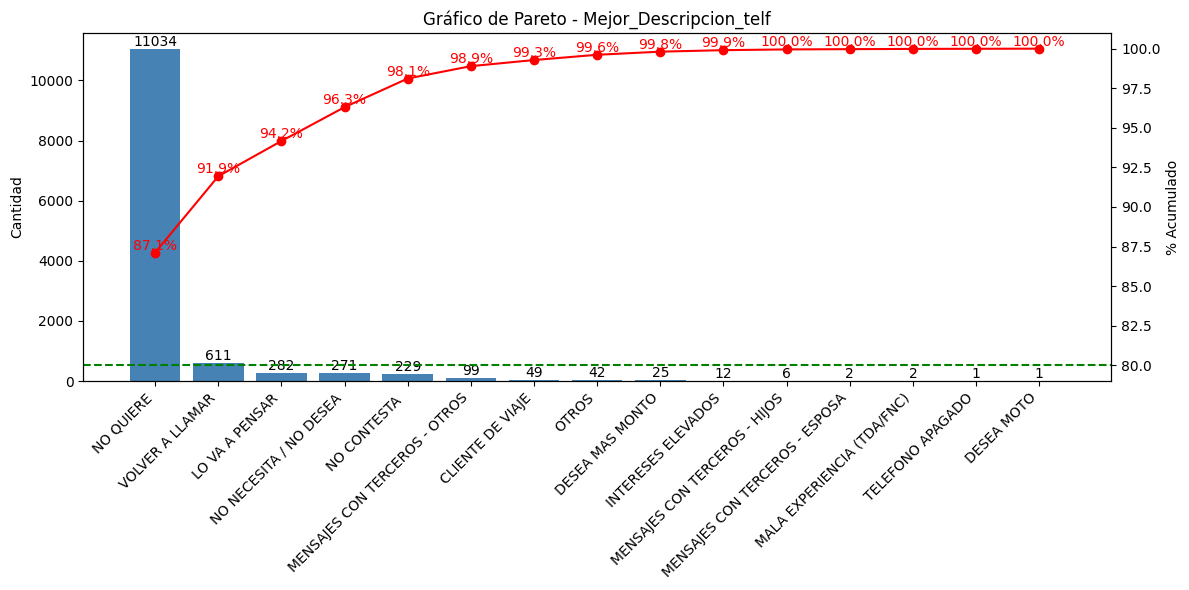

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar SIN GESTION
# df_filtrado = df_cen_sae[
#     ~df_cen_sae["Mejor_Descripcion_Telefono"].str.contains("SIN GESTION", na=False)
# ]
# df_filtrado = df_cen_sae[
#     (~df_cen_sae["Mejor_Descripcion_Telefono"].str.contains("SIN GESTION", na=False)) &
#     (df_cen_sae["Tipo_Telf"].isin(['BBDD CEL01','BBDD CEL03','BBDD CEL02']))&
#     (df_cen_sae["PROPENSION"].isin(['ALTO','BAJO']))
# ]

# Conteo ordenado
conteo = df_dni["mejor15_descripcion_telf"] \
            .value_counts() \
            .sort_values(ascending=False)

# % acumulado
porc_acum = conteo.cumsum() / conteo.sum() * 100

fig, ax1 = plt.subplots(figsize=(12,6))

# 🔵 Barras
bars = ax1.bar(conteo.index, conteo.values, color="steelblue")
ax1.set_ylabel("Cantidad")

# 👉 Etiquetas de cantidad en barras
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha="right")

# 🔴 Línea acumulada
ax2 = ax1.twinx()
ax2.plot(conteo.index, porc_acum, color="red", marker="o")
ax2.set_ylabel("% Acumulado")

# 👉 Etiquetas de % acumulado
for i, txt in enumerate(porc_acum):
    ax2.text(i, txt, f"{txt:.1f}%", color="red", ha="center", va="bottom")

# Línea 80%
ax2.axhline(80, color="green", linestyle="--")

plt.title("Gráfico de Pareto - Mejor_Descripcion_telf")
plt.tight_layout()
plt.show()

In [25]:
df_filtrado = .select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()
import os
ruta_archivo = os.path.join(ruta_csv, 'negocio_2026040130930.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [ ]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor_estado_tipi_cli' ] for row in df_list.select('mejor_estado_tipi_cli').distinct().collect()])
# print(df_list.columns)


['NO CONTACTO', 'CONTACTO TERCERO', 'CONTACTO EFECTIVO', None]


# cargar lista 

In [80]:


filename='CARGA 1604 TIPO X10.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)

In [60]:
print(df_prueba.columns)

['NUMDOCUMENTO', 'CELULAR1']


In [ ]:
['Nro_Tarjeta', 'DNI', 'CUS1', 'IdenCuenta', 'Probabilidad', 'Nombre_Producto', 'TipoTarjeta', 'Estado_Tarjeta', 'TEA_FORMATO', 'TEM_FORMATO', 'MONTO_PPD', 'prioridad_PPD', 'Deuda_tc_BCP', 'Deuda_tc_Continental', 'Deuda_tc_ScotiaBank', 'Deuda_tc_Interbank', 'Deuda_tc_falabella', 'Deuda_tc_total', 'Fecha_Expiracion', 'Tel1', 'Tel2', 'Tel3', 'Tel4', 'Nombre_Largo', 'Nombre', 'ApPaterno', 'ApMaterno', 'Ciclo', 'FechaNacimiento', 'Nacionalidad', 'EstadoCivil', 'Conyuge', 'Alerta_Diners', 'Direccion_Correspondencia', 'Distrito_Correspondencia', 'Provincia_Correspondencia', 'Departamento_Correspondencia', 'Direccion_Domicilio', 'Distrito', 'Provincia', 'Departamento', 'RazonSocial_Empresa', 'RUC_Empresa', 'Cargo', 'Profesion', 'Direccion_Lab', 'Distrito_Lab', 'Provincia_Lab', 'Departamento_Lab', 'Flag_entrega', 'mes_entrega', 'FLAG_ADICION', 'FLAG_CAD', 'NOMBRE_adic1', 'ApPaterno1', 'ApMaterno1', 'NOMBRE_adic2', 'ApPaterno2', 'ApMaterno2', 'NOMBRE_adic3', 'ApPaterno3', 'ApMaterno3', 'NOMBRE_adic4', 'ApPaterno4', 'ApMaterno4', 'NOMBRE_adic5', 'ApPaterno5', 'ApMaterno5', 'TIPO_PRODUCTO', 'correo', 'restriccion_total_call', 'CANAL_ASIGNADO', 'ASESOR_ASIGNADO', 'DNI_ASESOR', 'FLG_SEGMENTO_DIGITAL', 'TASA_APP', 'Prioridad_Modelo_PPD_efec', 'RECENCIA']

['NUMDOCUMENTO']

In [7]:
df_prueba=df_prueba.select('DNI','Prioridad_Modelo_PPD_efec','RECENCIA')

In [ ]:
# overwrite_table_SQL(spark,df_prueba,'tb_prueba_borrar_dinner_prestamo',server_sa,user_sa,pwd_sa,'CRONOX')
# overwrite_table_SQL(spark,df_prueba,'tb_prueba_borrar_dinner_prestamo',server_kishin,user_kishin,pwd_kishin,'DANTALION')
# overwrite_table_SQL(spark,df_prueba,'tb_prueba_borrar_dinner_prestamo',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
['NUMDOCUMENTO', 'CELULAR1']


In [81]:

query=f'''
    select * from cronox.dbo.borrar_negocio_efe
'''
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
print(df_list.count())


print(df_list.columns)
df_prueba.count()


449937
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'marca', 'fecha_envio', 'retiro', 'region', 'prioridada', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf']


19258

In [82]:

df_prueba = df_prueba.withColumn(
    "vendor_lead_code",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMDOCUMENTO")),
        F.lit(8)
    )
)

In [83]:
df_prueba = df_prueba.withColumn(
    "phone_number",F.col("CELULAR1")
)

In [84]:

print(df_prueba.columns)
print(df_list.columns)

['NUMDOCUMENTO', 'CELULAR1', 'vendor_lead_code', 'phone_number']
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'marca', 'fecha_envio', 'retiro', 'region', 'prioridada', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf']


In [85]:
df_prueba=df_prueba.select( 'vendor_lead_code', 'phone_number')

In [86]:

df_list=df_list.drop('phone_number')
df_list=df_list.join(df_prueba,['vendor_lead_code'],'inner')

print(df_list.count())

df_list = df_list.dropDuplicates(['vendor_lead_code'])
df_list.count()

103138


19257

In [ ]:
tipo_telf='BBDD CEL04'

In [15]:
df_list.groupBy('tipo_telf') \
    .count() \
    .orderBy('tipo_telf') \
    .show(30)

+----------+-----+
| tipo_telf|count|
+----------+-----+
|BBDD CEL01|   23|
|BBDD CEL02| 1855|
|BBDD CEL03|  824|
|BBDD CEL04|  481|
|BBDD CEL05|  253|
|BBDD CEL06|  171|
|BBDD CEL07|  121|
|BBDD CEL08|   58|
|BBDD CEL09|   39|
|BBDD CEL10|   36|
|BBDD CEL11|   18|
|BBDD CEL12|   10|
|BBDD CEL13|   11|
|BBDD CEL14|    4|
|BBDD CEL15|    7|
|BBDD EINT1| 1616|
|BBDD EINT2|   89|
|BBDD EIP01| 1958|
|BBDD EIP02| 1306|
|BBDD EIP03|  966|
|BBDD EIP04|  674|
|BBDD EIP05|  519|
|BBDD EPC01|  130|
|BBDD EPC02|  127|
|BBDD EPC03|   69|
|BBDD ETK01|  123|
|BBDD ETK02|   36|
|BBDD ETK03|   20|
|BBDD ETK04|    2|
|BBDD ETK05|    2|
+----------+-----+
only showing top 30 rows


In [87]:




df_list = df_list.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments',
)

df_dni = df_list.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'CARGA 1604 TIPO X10.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [ ]:
filename='CARGA 1604 TIPO X10.csv'


In [7]:

query=f'''
    select * from cronox.dbo.borrar_negocio_efe
'''
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
print(df_list.count())


filename='ELITE 1504.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)

print(df_list.columns)
print(df_prueba.columns)

449937
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'marca', 'fecha_envio', 'retiro', 'region', 'prioridada', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf']
['NUMDOCUMENTO', 'CELULAR1']


In [8]:
df_prueba=df_prueba.withColumnRenamed('CELULAR1','phone_number')
df_prueba=df_prueba.withColumnRenamed('NUMDOCUMENTO','vendor_lead_code')


In [9]:

df_prueba.count()


df_prueba = df_prueba.withColumn(
    "vendor_lead_code",
    F.right(
        F.concat(F.lit("00000000"), F.col("vendor_lead_code")),
        F.lit(8)
    )
)
df_prueba = df_prueba.filter(
    F.col("phone_number").rlike(r"^9\d{0,8}$")
)
df_list=df_list.drop('phone_number')

In [ ]:

df_list=df_list.join(df_prueba,['vendor_lead_code'],'inner')

# print(df_list.count())

df_list = df_list.dropDuplicates(['vendor_lead_code', 'phone_number'])

df_list = df_list.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)

df_dni = df_list.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'ELITE 1504.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

print(df_dni.count())

vendor_lead_code    24261
phone_number        24261
title               24261
first_name          24261
last_name           24261
address1            24261
address2                0
address3            24261
city                24261
province            24261
email               24261
security_phrase     18438
comments            24261
dtype: int64


vendor_lead_code    19700
phone_number        19700
title               19700
first_name          19700
last_name           19700
address1            19700
address2                0
address3            19700
city                19700
province            19700
email               19700
security_phrase     16038
comments            19700
dtype: int64